In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__  #('2.2.1+cu121', '2.2.2')

('2.8.0+cu126', '2.5.5')

## MLP, CNN Parameter 비교

In [4]:
from torchvision.datasets import MNIST

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size = 512
download_root = ''
train_dataset = MNIST(download_root, train=True, download=True, transform=transform)
test_dataset = MNIST(download_root, train=False, download=True, transform=transform)
trainDataLoader = DataLoader(train_dataset, batch_size, True,num_workers=4)
valDataLoader = DataLoader(test_dataset, batch_size, False,num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.35MB/s]


[] Shapetorch.Size([60000, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([60000]), <class 'torch.Tensor'>


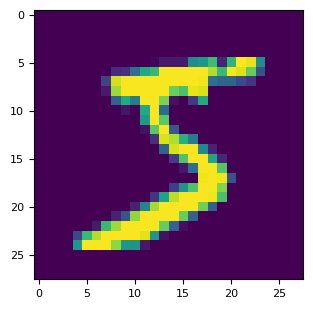

In [5]:
pst(trainDataLoader.dataset.data)    # image
pst(trainDataLoader.dataset.targets) # label
plt.imshow(trainDataLoader.dataset.data[0])
plt.show()

In [6]:
batch_n = len(trainDataLoader.dataset.data) // batch_size
batch_n

117

In [7]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

### MLP Model

In [8]:
# MLP model
class MLP(Wrap_10):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(  # Container
            nn.Flatten(),
            nn.Linear(28*28, 384),
            nn.ReLU(),
            nn.Linear(384, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

mlp = MLP()
summary(mlp, input_size=(batch_size, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [512, 10]                 --
├─Sequential: 1-1                        [512, 10]                 --
│    └─Flatten: 2-1                      [512, 784]                --
│    └─Linear: 2-2                       [512, 384]                301,440
│    └─ReLU: 2-3                         [512, 384]                --
│    └─Linear: 2-4                       [512, 10]                 3,850
Total params: 305,290
Trainable params: 305,290
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 156.31
Input size (MB): 1.61
Forward/backward pass size (MB): 1.61
Params size (MB): 1.22
Estimated Total Size (MB): 4.44

In [9]:
%%time
model = MLP()

epochs = 10
name="mlp"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, valDataLoader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


CPU times: user 9.85 s, sys: 2.86 s, total: 12.7 s
Wall time: 39.9 s


Wall time: 55.7 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

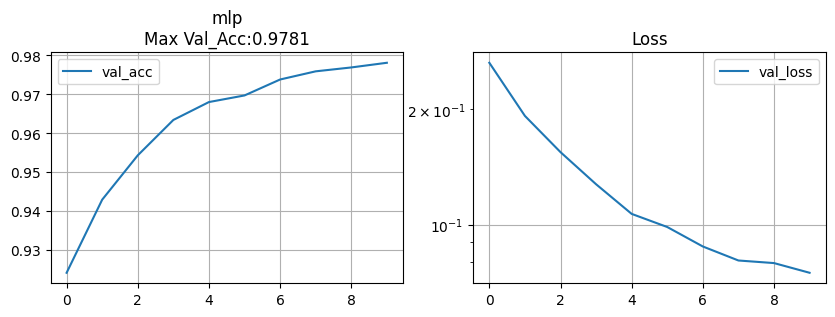

### CNN Model

In [10]:
nn.Conv2d(3, 7, (3, 3), stride=1, padding=1)
nn.Conv2d(3, 7, 3, padding='same')

Conv2d(3, 7, kernel_size=(3, 3), stride=(1, 1), padding=same)

In [11]:
class CNN(Wrap_10):
    def __init__(self):
        super(CNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, (3, 3), stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 32, (3, 3), stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*6*6, 10) )

    def forward(self, x):
        out = self.layers(x)
        return out

cnn = CNN()
summary(cnn, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [512, 10]                 --
├─Sequential: 1-1                        [512, 10]                 --
│    └─Conv2d: 2-1                       [512, 32, 13, 13]         320
│    └─ReLU: 2-2                         [512, 32, 13, 13]         --
│    └─Conv2d: 2-3                       [512, 32, 6, 6]           9,248
│    └─ReLU: 2-4                         [512, 32, 6, 6]           --
│    └─Flatten: 2-5                      [512, 1152]               --
│    └─Linear: 2-6                       [512, 10]                 11,530
Total params: 21,098
Trainable params: 21,098
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 204.05
Input size (MB): 1.61
Forward/backward pass size (MB): 26.91
Params size (MB): 0.08
Estimated Total Size (MB): 28.60

In [12]:
%%time
model = CNN()

model_name="cnn"
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, valDataLoader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


CPU times: user 9.83 s, sys: 2.8 s, total: 12.6 s
Wall time: 39.8 s


Wall time: 43.2 s

In [13]:
v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{v_num}/metrics.csv')

In [ ]:
h2 = history.drop('step', axis=1).groupby('epoch').last()
max_1 = h1['val_acc'].max()
max_2 = h2['val_acc'].max()

plt.figure(figsize=(10,3))
title = "MLP / CNN"
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_1:.4f} / {max_2:.4f}")
plt.plot(h1['val_acc'],'--', label='val_acc1')
plt.plot(h2['val_acc'], label='val_acc2')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['val_loss'],'--', label='val_loss1')
plt.plot(h2['val_loss'], label='val_loss2')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

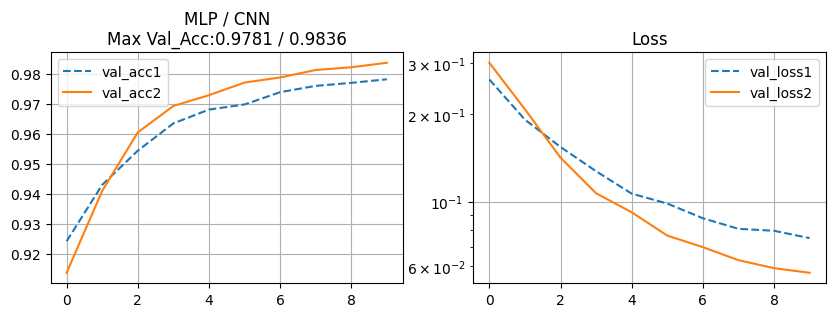

# 실습과제1 MNIST
LeNet-5와 유사한 모델을 만들어보자
- 모델을 개선하여 10epoch Val-acc 99%를 넘겨 보자  

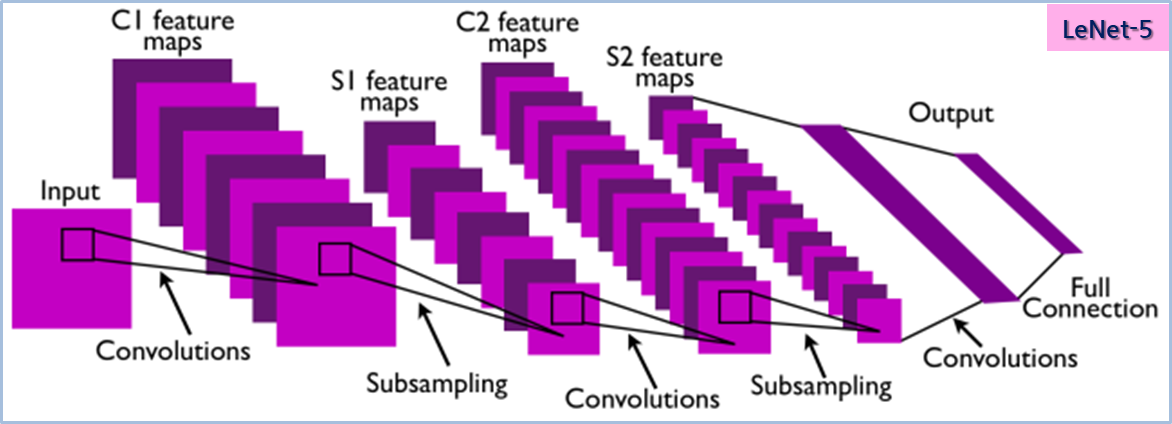

## LeNet like

In [15]:
class LeNet_like(Wrap_10):
    def __init__(self):
        super(LeNet_like, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 8, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(8, 16, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16, 32, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(32*3*3, 10)
           )

    def forward(self, x):
        out = self.layers(x)
        return out

LeNet = LeNet_like()
summary(LeNet, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet_like                               [512, 288]                --
├─Sequential: 1-1                        [512, 288]                --
│    └─Conv2d: 2-1                       [512, 8, 28, 28]          80
│    └─ReLU: 2-2                         [512, 8, 28, 28]          --
│    └─MaxPool2d: 2-3                    [512, 8, 14, 14]          --
│    └─Conv2d: 2-4                       [512, 16, 14, 14]         1,168
│    └─ReLU: 2-5                         [512, 16, 14, 14]         --
│    └─MaxPool2d: 2-6                    [512, 16, 7, 7]           --
│    └─Conv2d: 2-7                       [512, 32, 7, 7]           4,640
│    └─ReLU: 2-8                         [512, 32, 7, 7]           --
│    └─MaxPool2d: 2-9                    [512, 32, 3, 3]           --
│    └─Flatten: 2-10                     [512, 288]                --
Total params: 5,888
Trainable params: 5,888
Non-trainable params: 0
Total mult-

In [ ]:
#%%time
model = LeNet_like()

name="LeNet"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)

Wall time: 1min

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

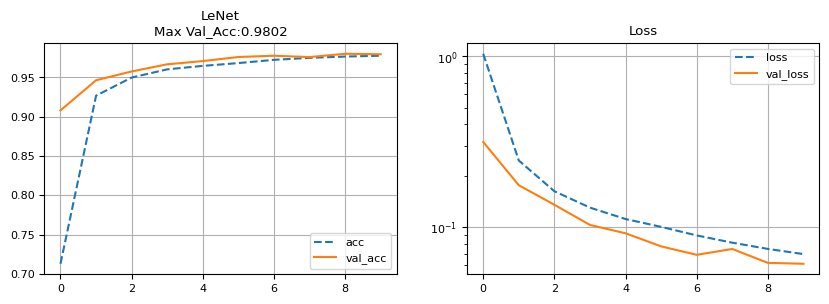

## LeNet like 수정


In [ ]:
# LeNet like model
class LeNet_like(Wrap_10):
    def __init__(self):
        super(LeNet_like, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 8, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(8, 16, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16, 32, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(32*3*3, 10)
           )

    def forward(self, x):
        out = self.layers(x)
        return out

model = LeNet_like()
summary(model, input_size=(batch_size, 1, 28, 28))

In [ ]:
%%time
model = LeNet_like()

name="LeNet-6"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)

Wall time: 49.3 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

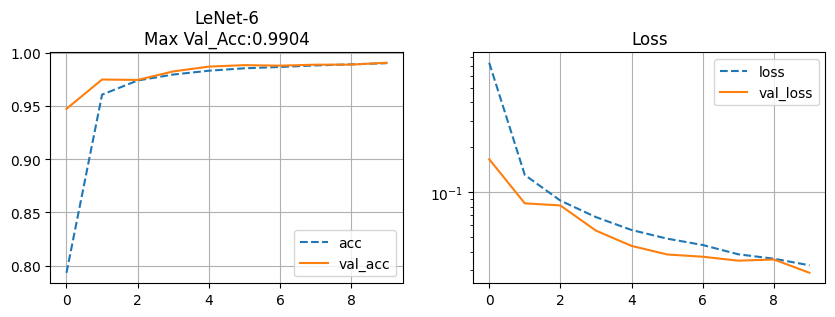

# 실습과제2 CIFAR-10

CIFAR-10 Datasetd을 적용해 보자
- 앞에서 만든 모델에 적용하자  
== input data shape (3,32,32)으로 수정하자  
== 모델을 개선하여 10epoch 에서 accuracy 73%를 넘겨 보자

In [16]:
from torchvision.datasets import CIFAR10
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size = 512
download_root = 'CIFAR10'
train_dataset = CIFAR10(download_root, train=True, download=True, transform=transform)
test_dataset = CIFAR10(download_root, train=False, download=True, transform=transform)
trainDataLoader = DataLoader(train_dataset, batch_size, True,num_workers=7)
valDataLoader = DataLoader(test_dataset, batch_size, False,num_workers=7)

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


[] Shape(50000, 32, 32, 3), <class 'numpy.ndarray'>
Label: 6


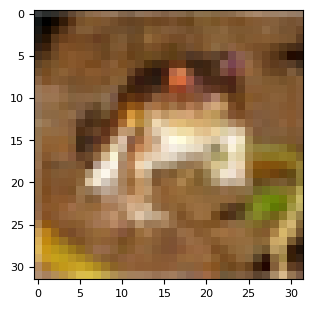

In [17]:
pst(trainDataLoader.dataset.data)     # image
print("Label:",trainDataLoader.dataset.targets[0]) # label
plt.imshow(trainDataLoader.dataset.data[0])
plt.show()

In [19]:
# LeNet like model
class LeNet_like(Wrap_10):
    def __init__(self):
        super(LeNet_like, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 8, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(8, 16, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(16, 32, (3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Flatten(),
#            nn.Dropout(0.4),
            nn.Linear(32*4*4, 10)
        )
    def forward(self, x):
        out = self.layers(x)
        return out

model = LeNet_like()
summary(model, input_size=(batch_size, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet_like                               [512, 2048]               --
├─Sequential: 1-1                        [512, 2048]               --
│    └─Conv2d: 2-1                       [512, 8, 32, 32]          224
│    └─ReLU: 2-2                         [512, 8, 32, 32]          --
│    └─MaxPool2d: 2-3                    [512, 8, 16, 16]          --
│    └─Conv2d: 2-4                       [512, 16, 16, 16]         1,168
│    └─ReLU: 2-5                         [512, 16, 16, 16]         --
│    └─MaxPool2d: 2-6                    [512, 16, 8, 8]           --
│    └─Conv2d: 2-7                       [512, 32, 8, 8]           4,640
│    └─ReLU: 2-8                         [512, 32, 8, 8]           --
│    └─Flatten: 2-9                      [512, 2048]               --
Total params: 6,032
Trainable params: 6,032
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 422.58
Input size (MB): 6.29
Forward/backward

In [ ]:
%%time
model = LeNet_like()
#epochs = 10

name="LeNet-C10"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

**With Dropout Layer**  
- val_acc가 training_acc보다 높은 이유는?

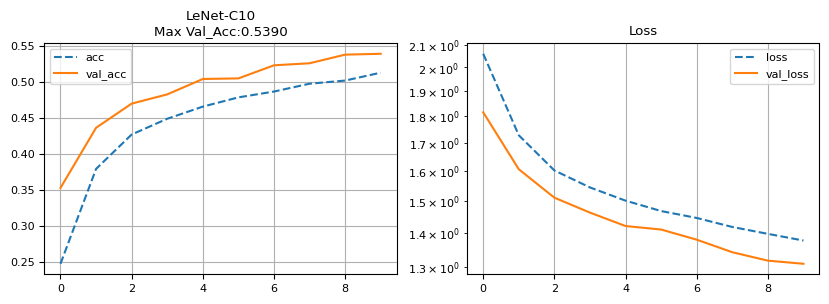

**Without Dropout Layer**   
-Dropout이 없는 상태에서 overffiting이 일어나야 함  

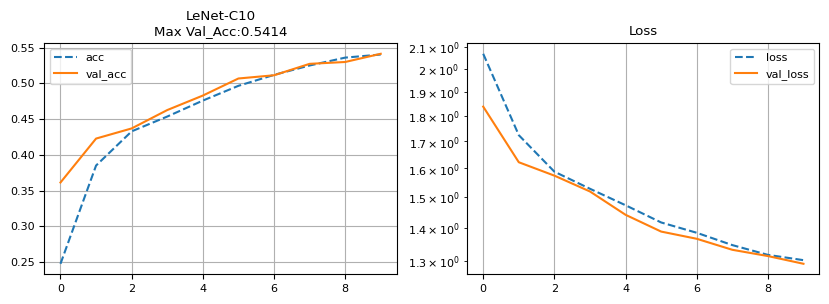

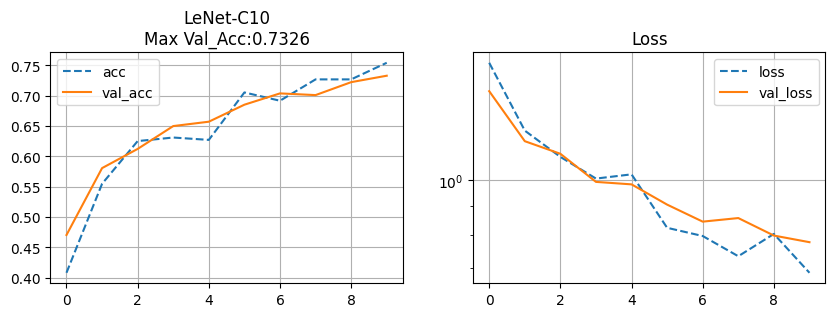